In [18]:
from pathlib import Path
import math, warnings, itertools, datetime as dt
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore")

def annualize(x, ann=252):
    return x.mean() * ann, x.std() * math.sqrt(ann)

def perf_metrics(eq, rets, ann=252):
    sharpe  = (rets.mean() / (rets.std() + 1e-12)) * math.sqrt(ann)
    neg_std = rets[rets < 0].std() + 1e-12
    sortino = (rets.mean() / neg_std) * math.sqrt(ann)
    peak    = np.maximum.accumulate(eq)
    max_dd  = np.max((peak - eq) / (peak + 1e-12))
    fin_wf  = eq[-1] / eq[0]
    ann_ret = fin_wf**(ann / len(rets)) - 1.0
    ann_vol = rets.std() * math.sqrt(ann)
    winrate = (rets > 0).mean()
    return dict(Sharpe=sharpe, Sortino=sortino, MaxDrawdown=max_dd,
                AnnualReturn=ann_ret, AnnualVol=ann_vol,
                FinalWealthFactor=fin_wf, WinRate=winrate)

def w_equal(n):
    return np.full(n, 1.0 / n)

def w_gmv(S):
    n = S.shape[0]
    w = cp.Variable(n)
    
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(S))),
                      [cp.sum(w) == 1, w >= 0])
    
    prob.solve(solver=cp.OSQP)
    
    # 만약 solver가 실패했을 경우에 대한 예외 처리 추가 (선택사항)
    if w.value is None:
         return np.full(n, 1.0 / n)
         
    return np.array(w.value).flatten()

def _cov_to_corr(S):
    std = np.sqrt(np.diag(S))
    denom = np.outer(std, std)
    corr = S / denom
    corr[np.isnan(corr)] = 0.0
    corr = np.clip(corr, -1.0, 1.0)
    return corr

def _get_hrp_order(S):
    corr = _cov_to_corr(S)
    dist = np.sqrt(0.5 * (1.0 - corr))
    dist = (dist + dist.T) / 2.0
    link = linkage(squareform(dist, checks=False),
                   method="single")
    return list(map(int, dendrogram(link, no_plot=True)["leaves"]))

def w_hrp(S):
    n = S.shape[0]
    sorted_idx = _get_hrp_order(S)
    w = pd.Series(1.0, index=sorted_idx)
    clusters = [[i] for i in sorted_idx]
    while len(clusters) > 1:
        new_clusters = []
        for i in range(0, len(clusters), 2):
            c1 = clusters[i]
            c2 = clusters[i+1] if i+1 < len(clusters) else []
            var1 = _cluster_var(S, c1)
            var2 = _cluster_var(S, c2) if c2 else var1
            alpha = 1 - var1/(var1+var2)
            w[c1] *= alpha
            w[c2] *= 1-alpha
            new_clusters.append(c1+c2)
        clusters = new_clusters
    w = w.sort_index()
    return w.values / w.sum()

def _cluster_var(S, cluster):
    sub = S[np.ix_(cluster, cluster)]
    inv = np.linalg.pinv(sub)
    ones = np.ones(len(cluster))
    w = inv @ ones
    w /= w.sum()
    return w.T @ sub @ w

def w_cvar_min(returns, alpha=0.95):
    N, T  = returns.shape
    w     = cp.Variable(N)
    zeta  = cp.Variable()
    u     = cp.Variable(T)

    loss  = -returns.T @ w
    obj   = zeta + (1/(1-alpha))/T * cp.sum(u)
    cons  = [cp.sum(w) == 1, w >= 0,
             u >= 0,
             u >= loss - zeta]

    prob  = cp.Problem(cp.Minimize(obj), cons)

    for solv, kwargs in [
        (cp.ECOS, dict(abstol=1e-8, reltol=1e-8, feastol=1e-8, max_iters=10_000)),
        (cp.SCS,  dict(eps=1e-5, max_iters=20_000)),
        (cp.OSQP, dict(eps_abs=1e-6, max_iter=20_000)),
    ]:
        try:
            prob.solve(solver=solv, **kwargs, verbose=False)
            if prob.status in ("optimal", "optimal_inaccurate"):
                return np.array(w.value).flatten()
        except (cp.SolverError, TypeError):
            continue

    warnings.warn("CVaR solver failed – falling back to equal weight")
    return np.full(N, 1.0 / N)

strategies = {
    "EW":   lambda **k: w_equal(k["n"]),
    "GMV":  lambda **k: w_gmv(k["S"]),
    "HRP":  lambda **k: w_hrp(k["S"]),
    "CVaR": lambda **k: w_cvar_min(k["hist_ret"]),
}

def run_one(asset_cnt, strategy_key,
            csv_path="dataset/full_dataset_csi2.csv",
            lookback=60): 
    df_full = pd.read_csv(csv_path, parse_dates=["Date"])
    df      = df_full.iloc[:, :asset_cnt + 1].copy()
    df.set_index("Date", inplace=True)

    df = df.loc["2017-01-01":"2018-03-21"].dropna()

    strat_dir = Path("./results_trad") / f"{strategy_key}_{asset_cnt}"
    strat_dir.mkdir(parents=True, exist_ok=True)
    csv_pos = strat_dir / "test_positions.csv"
    png_eq  = strat_dir / "test_equity_curve.png"
    csv_met = strat_dir / "test_metrics.csv"


    rebal_dates_str = [
'2017-02-28',
 '2017-03-31',
 '2017-04-28',
 '2017-05-31',
 '2017-06-30',
 '2017-07-31',
 '2017-08-31',
 '2017-09-29',
 '2017-10-31',
 '2017-11-30',
 '2017-12-29',
 '2018-01-31',
 '2018-02-28'
]

    
    rebal_dates_dt = pd.to_datetime(rebal_dates_str)

    valid_rebal_dates = [d for d in rebal_dates_dt if d in df.index and df.index.get_loc(d) >= lookback]

    asset_names = df.columns.tolist()
    record = {}  

    for i in range(len(valid_rebal_dates)):
        rebal_date = valid_rebal_dates[i]
        t0 = df.index.get_loc(rebal_date)


        if i + 1 < len(valid_rebal_dates):
            next_rebal_date = valid_rebal_dates[i+1]
            future_end_loc = df.index.get_loc(next_rebal_date)
        else:
            future_end_loc = len(df)

        hist   = df.iloc[t0 - lookback:t0]
        future = df.iloc[t0:future_end_loc]

        mu = hist.mean().values
        S  = np.cov(hist.values, rowvar=False) + 1e-8 * np.eye(asset_cnt)
        hist_mat = hist.values.T
        w_fun = strategies[strategy_key]
        w = w_fun(n=asset_cnt, mu=mu, S=S, hist_ret=hist_mat)

        for j, d in enumerate(future.index):
            if d in record:
                continue
            r = future.iloc[j].values
            port_ret = (w * r).sum()
            record[d] = (port_ret, w.copy())

    sorted_dates = sorted(record)
    initial_cap  = 10_000.0
    capital      = initial_cap
    equity_curve = [capital]
    daily_rets   = []
    rows         = []

    for d in sorted_dates:
        ret_scalar, w_vec = record[d]
        prev_cap = capital
        pnl      = ret_scalar * prev_cap
        capital += pnl
        equity_curve.append(capital)
        daily_rets.append(pnl / (prev_cap + 1e-12))

        row = {"Date": d.strftime("%Y-%m-%d"),
               "DailyPnL": pnl,
               "CumulativeCapital": capital}
        for i, name in enumerate(asset_names):
            row[f"Weight_{name}"] = float(w_vec[i])
        rows.append(row)

    pd.DataFrame(rows).to_csv(csv_pos, index=False)

    eq   = np.asarray(equity_curve)
    rets = np.asarray(daily_rets)
    pd.DataFrame([perf_metrics(eq, rets)]).to_csv(csv_met, index=False)

    plt.figure(figsize=(10, 5))
    plt.plot(eq, label=strategy_key)
    plt.title(f"Equity Curve – {strategy_key} | N={asset_cnt}")
    plt.xlabel("Step"); plt.ylabel("Capital")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(png_eq); plt.close()
    print(f"[{strategy_key}] Done  →  {strat_dir}")

# ---------------------------------------------------------------------------
if __name__ == "__main__":
    for N in [50, 100]:
        for key in strategies:
            run_one(asset_cnt=N, strategy_key=key)

[EW] Done  →  results_trad/EW_50
[GMV] Done  →  results_trad/GMV_50
[HRP] Done  →  results_trad/HRP_50
[CVaR] Done  →  results_trad/CVaR_50
[EW] Done  →  results_trad/EW_100
[GMV] Done  →  results_trad/GMV_100
[HRP] Done  →  results_trad/HRP_100
[CVaR] Done  →  results_trad/CVaR_100



=== Metrics (N=50) ===
          Sharpe  Sortino  MaxDrawdown  AnnualReturn  AnnualVol  \
Strategy                                                          
CVaR      0.8292   1.0038       0.1220        0.1120     0.1399   
EW        1.1695   1.3671       0.1263        0.1634     0.1376   
GMV       1.6717   2.1255       0.0942        0.2048     0.1155   
HRP       1.7428   2.0183       0.1136        0.2117     0.1140   

          FinalWealthFactor  WinRate  
Strategy                              
CVaR                 1.0971   0.5182  
EW                   1.1413   0.5636  
GMV                  1.1766   0.5409  
HRP                  1.1825   0.5636  

=== Metrics (N=100) ===
          Sharpe  Sortino  MaxDrawdown  AnnualReturn  AnnualVol  \
Strategy                                                          
CVaR      1.5199   2.0863       0.1155        0.3392     0.2060   
EW        1.1179   1.2660       0.1302        0.1447     0.1283   
GMV       1.5365   2.0612       0.1175        

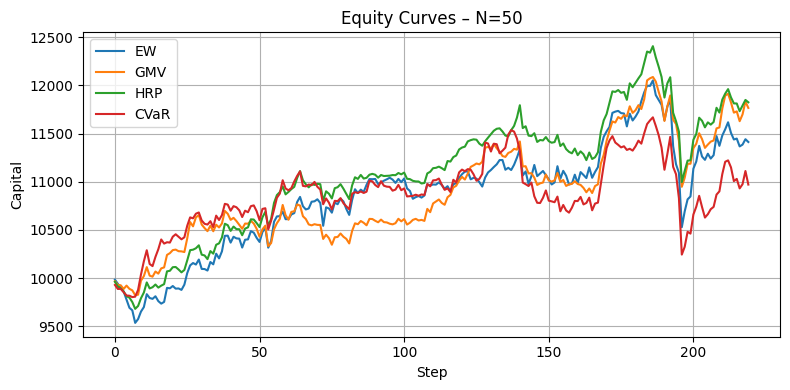

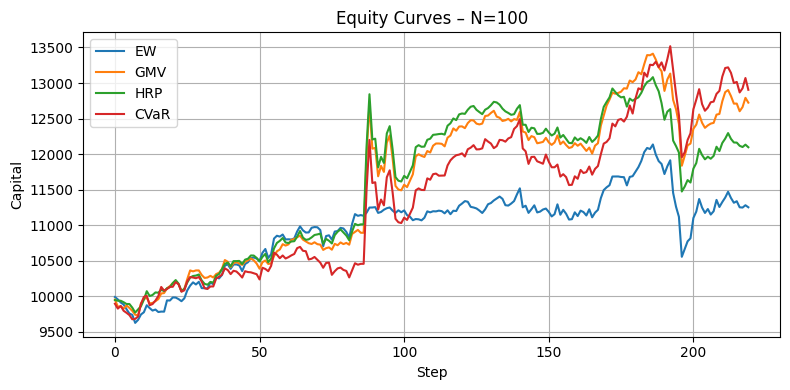

In [19]:
# metrics_equity_view.py  ─────────────────────────────────────────────
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

strategies = ["EW", "GMV",  "ERC", "HRP", "CVaR"]
Ns         = [50, 100]
base_dir   = Path("./results_trad")    


rows = []
for N in Ns:
    for s in strategies:
        f = base_dir / f"{s}_{N}" / "test_metrics.csv"
        if f.exists():
            d = pd.read_csv(f).iloc[0].to_dict()
            d.update({"N": N, "Strategy": s})
            rows.append(d)

metrics_all = pd.DataFrame(rows)

metrics_all = (metrics_all
               .set_index(["N", "Strategy"])
               .sort_index()
               .round(4))     

for N, grp in metrics_all.groupby(level=0):
    print(f"\n=== Metrics (N={N}) ===")
    print(grp.droplevel(0))          


for N in Ns:
    plt.figure(figsize=(8, 4))
    found = False
    for s in strategies:
        pos_f = base_dir / f"{s}_{N}" / "test_positions.csv"
        if pos_f.exists():
            cap = pd.read_csv(pos_f)["CumulativeCapital"]
            plt.plot(cap, label=s)
            found = True
    if found:
        plt.title(f"Equity Curves – N={N}")
        plt.xlabel("Step"); plt.ylabel("Capital")
        plt.grid(True); plt.legend(); plt.tight_layout()
        plt.show()
    else:
        print(f"[Warning] test_positions.csv not found for N={N}")


In [20]:
metrics_all[["Sharpe", "Sortino", "MaxDrawdown","FinalWealthFactor"]]

Sharpe  Sortino  MaxDrawdown  FinalWealthFactor
N   Strategy                                                 
50  CVaR      0.8292   1.0038       0.1220             1.0971
    EW        1.1695   1.3671       0.1263             1.1413
    GMV       1.6717   2.1255       0.0942             1.1766
    HRP       1.7428   2.0183       0.1136             1.1825
100 CVaR      1.5199   2.0863       0.1155             1.2905
    EW        1.1179   1.2660       0.1302             1.1252
    GMV       1.5365   2.0612       0.1175             1.2724
    HRP       1.2424   1.6540       0.1229             1.2097